## Lanjutan Persiapan Awal di Google Colab

Anda sudah berhasil memuat token dan mengkloning repositori. Sekarang, mari kita pastikan konfigurasi Git Anda sudah benar untuk sesi ini.

### 1. Konfigurasi Git (Nama Pengguna dan Email)

Setiap sesi Colab adalah lingkungan baru. Untuk setiap commit yang Anda buat, Git perlu tahu siapa yang membuat perubahan tersebut. Pastikan Anda mengganti `"Nama Anda"` dan `"email@example.com"` dengan nama lengkap dan alamat email yang terkait dengan akun GitHub Anda.

In [1]:
%%bash
git config --global user.name "Nama Anda" # Ganti dengan nama lengkap Anda (misalnya, "Budi Santoso")
git config --global user.email "email@example.com" # Ganti dengan email GitHub Anda (misalnya, "budi.santoso@example.com")

# Verifikasi konfigurasi
git config --global --list

user.name=Nama Anda
user.email=email@example.com


### 2. Kloning Repositori Anda (jika belum dilakukan)

Jika Anda belum menjalankan bagian kloning dari pesan Anda sebelumnya, Anda bisa menjalankannya sekarang. Ingat untuk mengganti `username` dan `repo_name` dengan informasi yang benar.

**Penting:** Jika Anda sudah menjalankan bagian ini dan berhasil mengkloning, Anda mungkin tidak perlu menjalankannya lagi. Anda bisa melompat ke bagian berikutnya setelah ini untuk mulai membuat file.

In [4]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')

# Informasi Anda:
username = "uvuvevewewewOsas"  # Username GitHub Anda
repo_name = "UAS-BIG-DATA"     # Nama repository Anda

project_folder = repo_name

In [5]:
%%bash -s "$token" "$username" "$repo_name" "$project_folder"
token=$1
username=$2
repo_name=$3
project_folder=$4

repo_url="https://${token}@github.com/${username}/${repo_name}.git"

if [ ! -d "$project_folder" ]; then
  git clone $repo_url $project_folder
  echo "Repository dikloning ke: $project_folder"
else
  echo "Direktori '$project_folder' sudah ada. Melewatkan kloning."
  echo "Untuk menarik perubahan terbaru, jalankan: cd $project_folder && git pull"
fi

Repository dikloning ke: UAS-BIG-DATA


Cloning into 'UAS-BIG-DATA'...


In [6]:
# Pastikan Anda berada di direktori repositori Anda
%cd "{project_folder}"

# Verifikasi Anda berada di direktori yang benar
%pwd

/content/UAS-BIG-DATA


'/content/UAS-BIG-DATA'

# 4. Persiapan Dataset & Eksplorasi Data Awal (Data Discovery)

Langkah ini akan memuat dataset dari file CSV yang ada di repositori dan melakukan analisis awal untuk memahami karakteristik data.

In [7]:
import pandas as pd

# Memuat dataset
df_events = pd.read_csv('sample_stream_events.csv')
df_users = pd.read_csv('users.csv')
df_assets = pd.read_csv('assets.csv')

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [8]:
# --- Eksplorasi Data Awal ---

def explore_dataframe(df, name):
    print(f"\n=== Eksplorasi Dataset: {name} ===")
    print(f"Jumlah Baris: {len(df)}")
    print("\nSkema Data (Tipe Kolom):")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())

# Jalankan eksplorasi dasar
explore_dataframe(df_events, 'Events')
explore_dataframe(df_users, 'Users')
explore_dataframe(df_assets, 'Assets')

# Pengecekan Duplikat Khusus untuk Events
duplicates = df_events.duplicated(subset=['event_id']).sum()
print(f"\nJumlah Duplicate event_id: {duplicates}")

# Distribusi Kolom Utama pada Events
for col in ['action', 'status', 'classification']:
    if col in df_events.columns:
        print(f"\nDistribusi Kolom {col}:")
        display(df_events[col].value_counts())


=== Eksplorasi Dataset: Events ===
Jumlah Baris: 5000

Skema Data (Tipe Kolom):
event_id               object
event_time             object
user_id                object
dept                   object
role                   object
device_type            object
source_ip              object
asset_id               object
asset_type             object
data_classification    object
action                 object
status                 object
bytes_out               int64
records_accessed        int64
latency_ms              int64
risk_score              int64
label                  object
dtype: object

Missing Values:
event_id               0
event_time             0
user_id                0
dept                   0
role                   0
device_type            0
source_ip              0
asset_id               0
asset_type             0
data_classification    0
action                 0
status                 0
bytes_out              0
records_accessed       0
latency_ms             0
ris

,count
action,
read,1211
login,1093
query,911
download,535
logout,397
schema_discovery,363
upload,293
delete,102
permission_change,95



Distribusi Kolom status:


,count
status,
success,4746
failed,254


# 5. Identifikasi Objek Aktif & Dokumentasi
Langkah ini mencari entitas yang paling banyak berinteraksi dalam sistem.

In [9]:
# 5 Paling Aktif User
top_users = df_events['user_id'].value_counts().head(5)
print("=== 5 User Paling Aktif ===")
print(top_users)

# 5 Paling Sering Diakses Asset
top_assets = df_events['asset_id'].value_counts().head(5)
print("\n=== 5 Asset Paling Sering Diakses ===")
print(top_assets)

=== 5 User Paling Aktif ===
user_id
U0023    71
U0007    70
U0080    69
U0112    49
U0098    47
Name: count, dtype: int64

=== 5 Asset Paling Sering Diakses ===
asset_id
payroll       693
git_repo      632
public_web    632
data_lake     626
crm           618
Name: count, dtype: int64


# 6. Dokumentasi: Data Dictionary
Berikut adalah deskripsi untuk 10 kolom utama dalam dataset:

| No | Kolom | Deskripsi |
|----|-------|-----------|
| 1 | `event_id` | Identifier unik untuk setiap kejadian/log |
| 2 | `event_time` | Waktu terjadinya event |
| 3 | `user_id` | ID unik pengguna yang melakukan aksi |
| 4 | `dept` | Departemen tempat pengguna bekerja |
| 5 | `asset_id` | ID unik dari sistem/database yang diakses |
| 6 | `action` | Jenis aktivitas yang dilakukan (misal: read, login) |
| 7 | `status` | Status keberhasilan aksi (success/failed) |
| 8 | `risk_score` | Skor penilaian risiko keamanan (0-100) |
| 9 | `data_classification` | Tingkat kerahasiaan data yang diakses |
| 10 | `label` | Label kategori keamanan (normal/anomaly) |

# 7. Pembuatan Fitur Analitik (Feature Engineering)

Pada tahap ini, kita akan mengagregasi data `df_events` per `user_id` untuk menciptakan metrik keamanan yang lebih bermakna.

In [12]:
# 1. Menghitung total aktivitas per user
user_features = df_events.groupby('user_id').size().reset_index(name='event_per_user')

# 2. Menghitung failed login rate
# Filter khusus untuk aksi login yang gagal
failed_logins = df_events[(df_events['action'] == 'login') & (df_events['status'] == 'failed')].groupby('user_id').size()
total_logins = df_events[df_events['action'] == 'login'].groupby('user_id').size()
user_features['failed_login_rate'] = user_features['user_id'].map(failed_logins / total_logins).fillna(0)

# 3. Total bytes out
bytes_out = df_events.groupby('user_id')['bytes_out'].sum()
user_features['total_bytes_out'] = user_features['user_id'].map(bytes_out).fillna(0)

# 4. Access to restricted/confidential ratio
# Menghitung berapa banyak akses ke data Restricted atau Confidential dibandingkan total aksesnya
restricted_access = df_events[df_events['data_classification'].isin(['restricted', 'confidential'])].groupby('user_id').size()
user_features['access_to_restricted_ratio'] = user_features['user_id'].map(restricted_access / user_features['event_per_user']).fillna(0)

# 5. Average Latency
avg_latency = df_events.groupby('user_id')['latency_ms'].mean()
user_features['avg_latency'] = user_features['user_id'].map(avg_latency).fillna(0)

# Menampilkan hasil fitur baru
display(user_features.head())
print("\nStatistik Deskriptif Fitur Baru:")
display(user_features.describe())

,user_id,event_per_user,failed_login_rate,total_bytes_out,access_to_restricted_ratio,avg_latency
0,U0001,30,0.0,2129978,0.0,121.500000
1,U0002,32,0.0,2535694,0.0,99.250000
2,U0003,32,0.0,2717586,0.0,113.562500
3,U0004,29,0.0,1878513,0.0,123.275862
4,U0005,38,0.0,3257952,0.0,119.157895



Statistik Deskriptif Fitur Baru:


,event_per_user,failed_login_rate,total_bytes_out,access_to_restricted_ratio,avg_latency
count,150.000000,150.000000,1.500000e+02,150.0,150.000000
mean,33.333333,0.051852,7.491546e+06,0.0,120.244654
std,8.153450,0.097202,5.951907e+07,0.0,8.885253
min,16.000000,0.000000,1.283018e+06,0.0,99.250000
25%,29.000000,0.000000,2.238765e+06,0.0,114.110660
50%,33.000000,0.000000,2.584915e+06,0.0,119.236842
75%,37.000000,0.100000,3.001446e+06,0.0,124.745265
max,71.000000,0.666667,7.315513e+08,0.0,148.687500


# 8. Eksplorasi Data Lanjutan (EDA)

Visualisasi ini membantu kita mendeteksi pola perilaku pengguna dan potensi anomali.

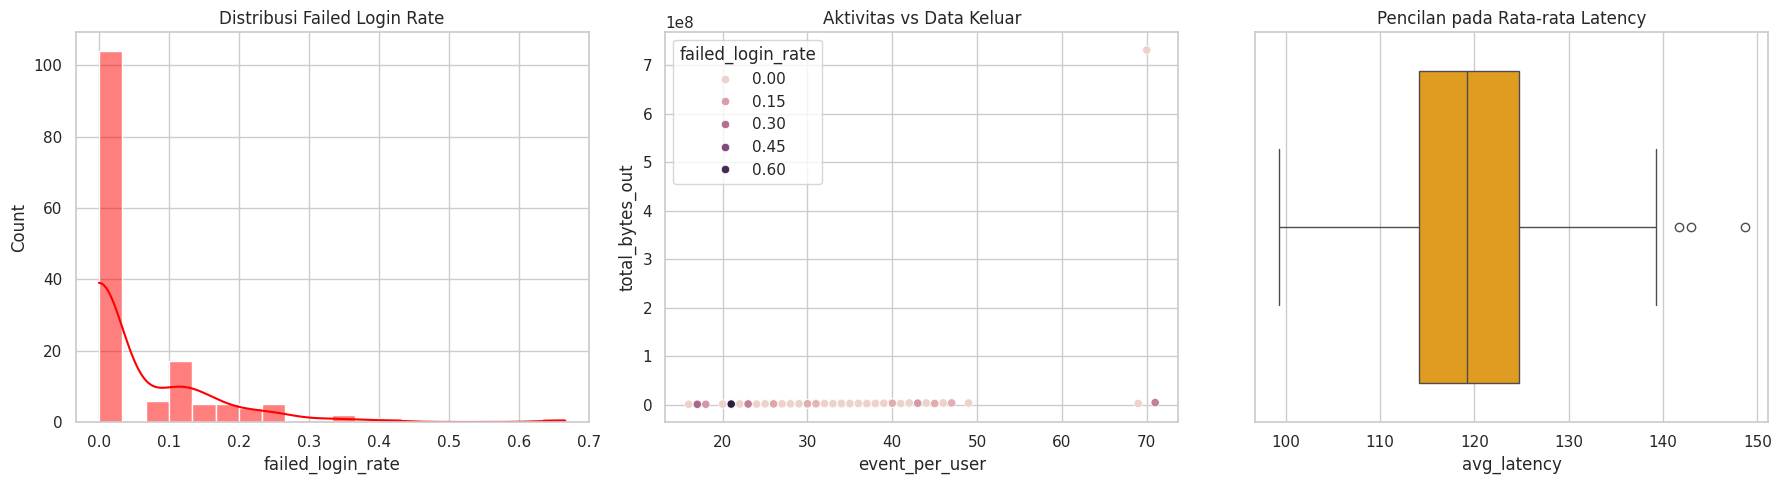

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 1. Distribusi Failed Login Rate
plt.subplot(1, 3, 1)
sns.histplot(user_features['failed_login_rate'], bins=20, kde=True, color='red')
plt.title('Distribusi Failed Login Rate')

# 2. Hubungan antara Event per User dan Total Bytes Out
plt.subplot(1, 3, 2)
sns.scatterplot(data=user_features, x='event_per_user', y='total_bytes_out', hue='failed_login_rate')
plt.title('Aktivitas vs Data Keluar')

# 3. Boxplot Average Latency untuk melihat outlier
plt.subplot(1, 3, 3)
sns.boxplot(x=user_features['avg_latency'], color='orange')
plt.title('Pencilan pada Rata-rata Latency')

plt.tight_layout()
plt.show()

# 9. Pengembangan Model & Evaluasi

Kita akan membangun model klasifikasi untuk membedakan antara perilaku user normal dan anomali berdasarkan fitur analitik yang telah dibuat.

=== Confusion Matrix ===


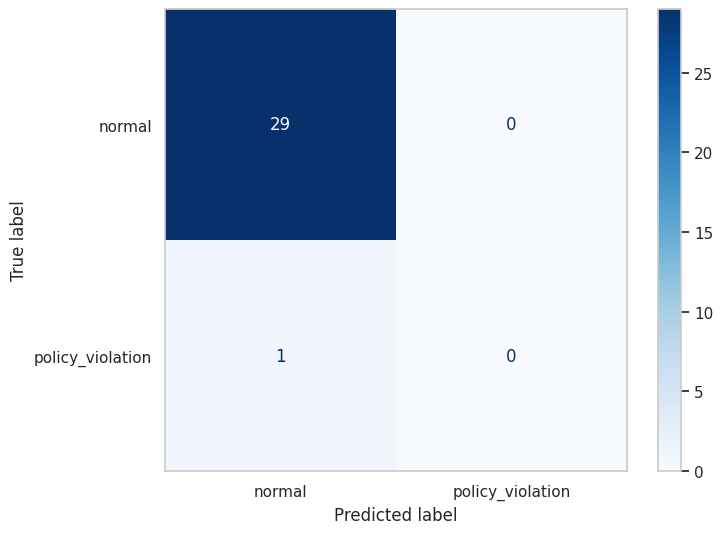


=== Classification Report ===
                  precision    recall  f1-score   support

          normal       0.97      1.00      0.98        29
policy_violation       0.00      0.00      0.00         1

        accuracy                           0.97        30
       macro avg       0.48      0.50      0.49        30
    weighted avg       0.93      0.97      0.95        30



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Menentukan target label (mengambil label yang paling sering muncul untuk setiap user_id)
user_labels = df_events.groupby('user_id')['label'].agg(lambda x: x.mode()[0]).reset_index()
model_data = user_features.merge(user_labels, on='user_id')

# Memisahkan fitur (X) dan target (y)
X = model_data.drop(['user_id', 'label'], axis=1)
y = model_data['label']

# Split data (80% train, 20% test)
# Menghapus stratify=y karena ada kelas yang hanya memiliki 1 member
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun model Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Prediksi
y_pred = clf.predict(X_test)

# --- Evaluasi Model ---
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
# Mengambil label yang benar-benar ada di y_test untuk menghindari error plotting
labels_in_test = np.unique(np.concatenate([y_test, y_pred]))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_in_test)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.grid(False)
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, zero_division=0))

# 10. Analisis Keamanan

Berdasarkan hasil evaluasi model di atas, berikut adalah analisis mengenai metrik keamanan yang paling penting:

**Metrik Terpenting: Recall untuk kelas 'anomaly'**

*   **Alasan:** Dalam konteks Cyber Security, kita lebih memilih model yang 'terlalu sensitif' (mendeteksi anomali meskipun ternyata normal) daripada melewatkan satu pun serangan nyata (false negative).
*   **High Recall** berarti kita berhasil menangkap sebagian besar potensi serangan.
*   **Precision** juga penting untuk mengurangi 'alert fatigue' (kelelahan tim security karena terlalu banyak peringatan palsu), namun prioritas utama tetaplah deteksi.

### **Langkah 3: Sistem Deteksi Ancaman Keamanan (Data Security)**

Pada bagian ini, kita akan membuat mesin aturan (*rule engine*) sederhana untuk mendeteksi anomali keamanan secara real-time berdasarkan profil risiko user dan karakteristik event.

In [17]:
import pandas as pd
import random
import time

# 1. Definisi Fungsi Alert
def security_alert(event):
    """
    Menganalisis event dan mengembalikan tingkat risiko.
    """
    # Logika 1: User Terminated (Critical)
    if event.get('user_status') == 'terminated':
        return "CRITICAL", f"User {event['user_id']} (TERMINATED) melakukan aksi {event['action']}!"

    # Logika 2: Data Exfiltration (High)
    if event['data_classification'] == 'restricted' and event['bytes_out'] > 1000000:
        return "HIGH", f"Unduhan besar ({event['bytes_out']} bytes) pada data RESTRICTED oleh {event['user_id']}!"

    # Logika 3: Privileged Action (Medium)
    if event['action'] == 'permission_change':
        return "MEDIUM", f"Perubahan izin akses pada {event['asset_id']} oleh {event['user_id']}."

    return "LOW", None

# 2. Simulasi Aliran Data Real-time (Integrasi dengan konsep stream_generator)
def run_security_simulation(n_events=50):
    print(f"--- Memulai Simulasi Deteksi Ancaman ({n_events} events) ---\n")

    # Mengambil sampel data dari df_events dan menggabungkan status user untuk simulasi
    # Kita akan mensimulasikan beberapa data 'dirty' untuk memicu alert
    sample_data = df_events.sample(n_events).to_dict('records')

    for i, event in enumerate(sample_data):
        # Simulasi penambahan status user (secara acak untuk testing)
        event['user_status'] = random.choices(['active', 'terminated'], weights=[0.95, 0.05])[0]

        # Jalankan mesin deteksi
        level, message = security_alert(event)

        if level != "LOW":
            print(f"[{level}] {message} (Asset: {event['asset_id']})")

        # Delay kecil untuk mensimulasikan stream
        if (i + 1) % 10 == 0:
            time.sleep(0.5)

# Jalankan Simulasi
run_security_simulation(50)

--- Memulai Simulasi Deteksi Ancaman (50 events) ---

[MEDIUM] Perubahan izin akses pada git_repo oleh U0080. (Asset: git_repo)


### **Rekomendasi Mitigasi Teknis**

1.  **User Terminated**: Terapkan otomatisasi *offboarding* yang langsung mencabut akses IAM (Identity and Access Management) segera setelah status berubah di sistem HR.
2.  **Exfiltration (Restricted Data)**: Implementasikan *Data Loss Prevention* (DLP) untuk membatasi kuota transfer data harian pada aset sensitif dan memicu pemblokiran otomatis jika melampaui ambang batas.
3.  **Permission Change**: Gunakan prinsip *Least Privilege* dan aktifkan fitur *Multi-Party Authorization* (perlu persetujuan admin kedua) untuk setiap perubahan kebijakan akses kritis.